In [1]:
import numpy as np

# Two tokens, each with 2 features
sequence = np.array([
    [0.2, 0.5],
    [0.7, 0.1]
])

print(sequence)
print("Shape:", sequence.shape)

[[0.2 0.5]
 [0.7 0.1]]
Shape: (2, 2)


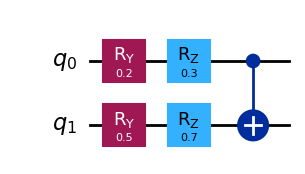

In [2]:
from qiskit import QuantumCircuit

def quantum_query_circuit(token):

    qc = QuantumCircuit(2)

    # Encode token features
    qc.ry(token[0], 0)
    qc.ry(token[1], 1)

    # Trainable-style transformation
    qc.rz(0.3, 0)
    qc.rz(0.7, 1)

    # Entanglement
    qc.cx(0, 1)

    return qc

qc_q = quantum_query_circuit(sequence[0])

qc_q.draw("mpl")

In [3]:
from qiskit.quantum_info import Statevector, Pauli

state = Statevector.from_instruction(qc_q)

z0 = state.expectation_value(Pauli("ZI")).real
z1 = state.expectation_value(Pauli("IZ")).real

query_vector = np.array([z0, z1])

print("Query Vector:")
print(query_vector)

Query Vector:
[0.86008934 0.98006658]


In [5]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Pauli

def get_quantum_vector(token, rx1, rx2):

    qc = QuantumCircuit(2)

    qc.ry(token[0], 0)
    qc.ry(token[1], 1)

    qc.rx(rx1, 0)
    qc.rx(rx2, 1)

    qc.cx(0, 1)

    state = Statevector.from_instruction(qc)

    z0 = state.expectation_value(Pauli("ZI")).real
    z1 = state.expectation_value(Pauli("IZ")).real

    return np.array([z0, z1])

token = sequence[0]

Q = get_quantum_vector(token, 0.3, 0.7)
K = get_quantum_vector(token, 0.9, 0.2)
V = get_quantum_vector(token, 1.4, 1.1)

print("Q =", Q)
print("K =", K)
print("V =", V)

Q = [0.6284515  0.93629336]
K = [0.5239829  0.60921915]
V = [0.06630982 0.16657912]


In [6]:
attention_score = np.dot(Q, K)

print("Attention Score:")
print(attention_score)

Attention Score:
0.8997056885122279


Token
 ↓
Quantum Projection
 ↓
Q

Token
 ↓
Quantum Projection
 ↓
K

Q·K
 ↓
Attention Score

In [7]:
# Token 1
Q1 = get_quantum_vector(sequence[0], 0.3, 0.7)
K1 = get_quantum_vector(sequence[0], 0.9, 0.2)
V1 = get_quantum_vector(sequence[0], 1.4, 1.1)

# Token 2
Q2 = get_quantum_vector(sequence[1], 0.3, 0.7)
K2 = get_quantum_vector(sequence[1], 0.9, 0.2)
V2 = get_quantum_vector(sequence[1], 1.4, 1.1)

print("Q1 =", Q1)
print("Q2 =", Q2)

Q1 = [0.6284515  0.93629336]
Q2 = [0.5560642  0.73068165]


In [8]:
attention_matrix = np.array([
    [np.dot(Q1, K1), np.dot(Q1, K2)],
    [np.dot(Q2, K1), np.dot(Q2, K2)]
])

print(attention_matrix)

[[0.89970569 0.73651339]
 [0.73651339 0.60519786]]


In [9]:
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

attention_weights = np.array([
    softmax(attention_matrix[0]),
    softmax(attention_matrix[1])
])

print(attention_weights)

[[0.54070777 0.45929223]
 [0.53278179 0.46721821]]


In [10]:
V_matrix = np.array([
    V1,
    V2
])

print("V Matrix:")
print(V_matrix)

output = attention_weights @ V_matrix

print("\nAttention Output:")
print(output)

V Matrix:
[[0.06630982 0.16657912]
 [0.05867202 0.12999804]]

Attention Output:
[[0.06280184 0.14977771]
 [0.0627413  0.14948777]]


### ✓ Quantum Q generation
### ✓ Quantum K generation
### ✓ Quantum V generation
### ✓ Attention matrix
### ✓ Softmax
### ✓ Attention output

# BUILT Quantum Self-Attention Layer